# Solution: Testes de Quebras Estruturais

Resolucoes completas dos testes de deteccao de quebras estruturais.

**Conteudo:**
1. Setup e geracao de dados
2. Teste de Chow completo (quebra conhecida)
3. CUSUM e CUSUM-sq completos
4. Bai-Perron completo (multiplas quebras endogenas)
5. Serie com duas quebras
6. Aplicacao: PIB do Brasil
7. **Exercicio 1 resolvido**: Sensibilidade do Bai-Perron ao trim
8. **Exercicio 2 resolvido**: Quebras no PIB dos EUA (2008, 2020)
9. Visualizacao consolidada
10. Tabela resumo com datas e intervalos de confianca
11. Exportacao de resultados em JSON

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

from chronobox.tests_stat import chow_test, cusum_test, cusumsq_test, bai_perron_test

import sys
sys.path.insert(0, '..')
from utils.data_generators import generate_structural_break
from utils.plot_helpers import plot_structural_break, plot_cusum

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Geracao de Series com Quebra Estrutural

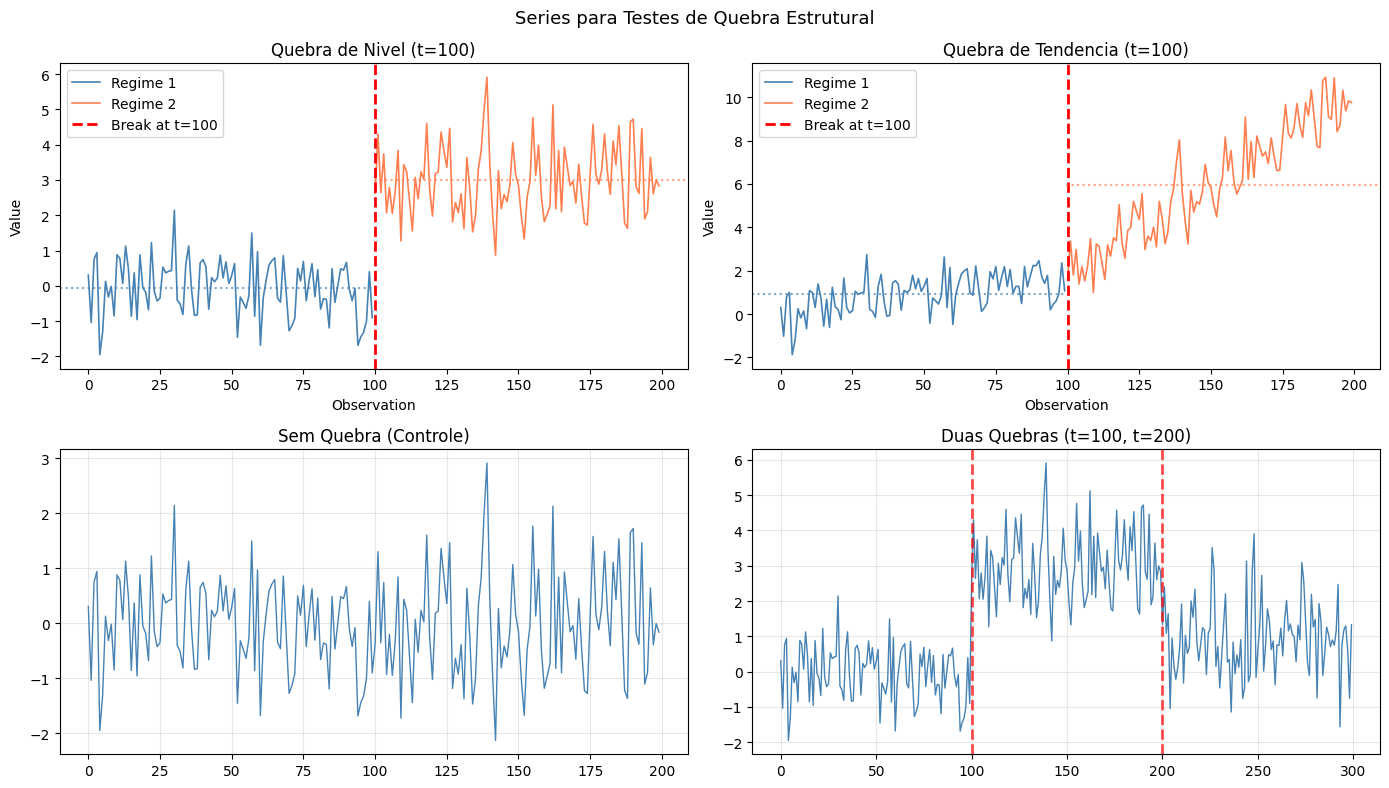

Quebra nivel: indice 100
Quebra tendencia: indice 100
Duas quebras: indices 100 e 200


In [2]:
# Serie com quebra de nivel (shift=3.0 no ponto medio)
df_level = generate_structural_break(n=200, break_point=0.5, shift=3.0, seed=42)
true_break_level = int(df_level['true_break_index'].iloc[0])

# Serie com quebra de tendencia
df_trend = generate_structural_break(n=200, break_point=0.5, shift=0.0, seed=42,
                                      trend_before=0.02, trend_after=0.08)
true_break_trend = int(df_trend['true_break_index'].iloc[0])

# Serie sem quebra (controle)
rng = np.random.default_rng(42)
y_stable = rng.normal(0, 1, 200)

# Serie com duas quebras
rng2 = np.random.default_rng(42)
n_two = 300
y_two_breaks = np.zeros(n_two)
y_two_breaks[:100] = rng2.normal(0, 1, 100)
y_two_breaks[100:200] = rng2.normal(3, 1, 100)
y_two_breaks[200:] = rng2.normal(1, 1, 100)

# Visualizacao
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_structural_break(pd.Series(df_level['y'].values), true_break_level,
                      title=f'Quebra de Nivel (t={true_break_level})', ax=axes[0, 0])
plot_structural_break(pd.Series(df_trend['y'].values), true_break_trend,
                      title=f'Quebra de Tendencia (t={true_break_trend})', ax=axes[0, 1])
axes[1, 0].plot(y_stable, color='steelblue', linewidth=1.0)
axes[1, 0].set_title('Sem Quebra (Controle)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(y_two_breaks, color='steelblue', linewidth=1.0)
for b in [100, 200]:
    axes[1, 1].axvline(x=b, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Duas Quebras (t=100, t=200)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Series para Testes de Quebra Estrutural', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Quebra nivel: indice {true_break_level}")
print(f"Quebra tendencia: indice {true_break_trend}")
print(f"Duas quebras: indices 100 e 200")

## 2. Teste de Chow Completo

In [3]:
def run_chow_complete(y, x_mat, break_point, name):
    """Roda Chow e retorna dicionario."""
    r = chow_test(y, x_mat, break_point=break_point)
    print(f"=== Chow: {name} (break={break_point}) ===")
    print(r.summary())
    decision = 'Quebra detectada' if r.reject_at_5pct else 'Sem quebra'
    print(f"Decisao a 5%: {decision}\n")
    
    result = {
        'test': 'Chow', 'series': name, 'break_point': int(break_point),
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }
    # Adicionar info extra se disponivel
    for key in ['SSR_full', 'SSR_1', 'SSR_2', 'T1', 'T2']:
        if key in r.additional_info:
            result[key] = float(r.additional_info[key])
    return result

# Preparar matriz de regressores
n = 200
t = np.arange(n)
x_mat = np.column_stack([np.ones(n), t])

chow_results = []

# Quebra de nivel - ponto correto
y_level = df_level['y'].values
chow_results.append(run_chow_complete(y_level, x_mat, true_break_level, 'Nivel (ponto correto)'))

# Quebra de nivel - ponto errado
chow_results.append(run_chow_complete(y_level, x_mat, 50, 'Nivel (ponto errado t=50)'))

# Quebra de tendencia - ponto correto
y_trend = df_trend['y'].values
chow_results.append(run_chow_complete(y_trend, x_mat, true_break_trend, 'Tendencia (ponto correto)'))

# Controle - serie estavel
chow_results.append(run_chow_complete(y_stable, x_mat, 100, 'Estavel (controle)'))

=== Chow: Nivel (ponto correto) (break=100) ===
  Chow Test
  Test statistic : 79.414306
  p-value        : 0.000000

  H0: Coefficients are constant (no structural break)
  H1: Structural break at index 100

  Critical Values:
       1% : 4.7151
      10% : 2.3298
       5% : 3.0420

  Decision (5%)  : Reject H0

  Additional Info:
    break_point: 100
    SSR_full: 276.330272
    SSR_1: 58.223192
    SSR_2: 94.415946
    T1: 100
    T2: 100
    df1: 2
    df2: 196
Decisao a 5%: Quebra detectada

=== Chow: Nivel (ponto errado t=50) (break=50) ===
  Chow Test
  Test statistic : 7.257938
  p-value        : 0.000910

  H0: Coefficients are constant (no structural break)
  H1: Structural break at index 50

  Critical Values:
       1% : 4.7151
      10% : 2.3298
       5% : 3.0420

  Decision (5%)  : Reject H0

  Additional Info:
    break_point: 50
    SSR_full: 276.330272
    SSR_1: 28.034833
    SSR_2: 229.241409
    T1: 50
    T2: 150
    df1: 2
    df2: 196
Decisao a 5%: Quebra detec

  Chow: Varredura de Pontos Candidatos
  t= 30: F=4.725, p=0.0099, rej=True
  t= 40: F=5.849, p=0.0034, rej=True
  t= 50: F=7.258, p=0.0009, rej=True
  t= 60: F=6.810, p=0.0014, rej=True
  t= 70: F=6.801, p=0.0014, rej=True
  t= 80: F=9.493, p=0.0001, rej=True
  t= 90: F=18.824, p=0.0000, rej=True
  t=100: F=79.414, p=0.0000, rej=True
  t=110: F=26.427, p=0.0000, rej=True
  t=120: F=9.667, p=0.0001, rej=True
  t=130: F=3.500, p=0.0321, rej=True
  t=140: F=1.952, p=0.1447, rej=False
  t=150: F=2.052, p=0.1313, rej=False
  t=160: F=2.055, p=0.1309, rej=False


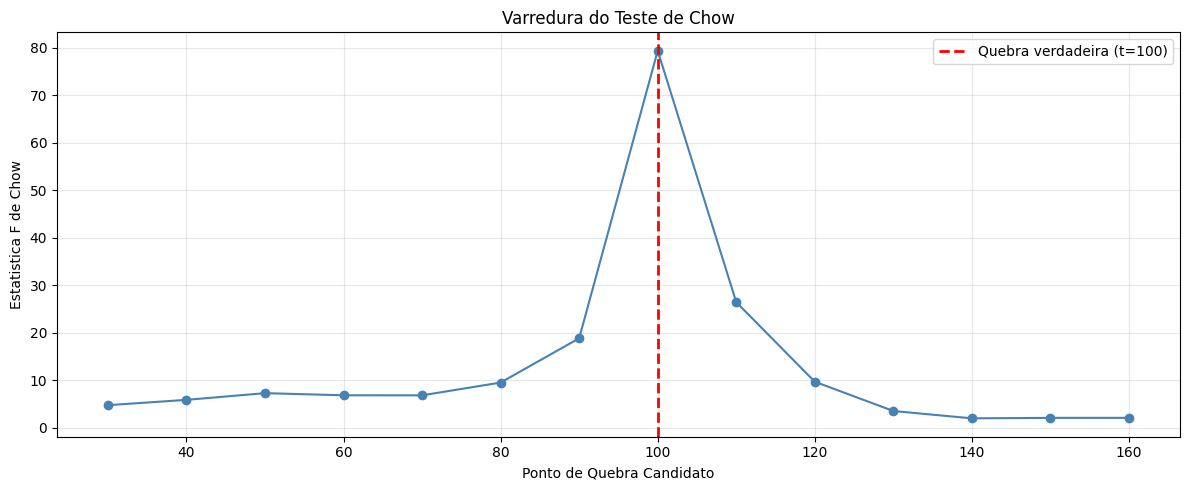


Ponto com maior F: t=100 (verdadeiro: t=100)


In [4]:
# Chow em multiplos pontos candidatos para a serie com quebra
print("="*70)
print("  Chow: Varredura de Pontos Candidatos")
print("="*70)

chow_scan = []
for bp in range(30, 170, 10):
    r = chow_test(y_level, x_mat, break_point=bp)
    chow_scan.append({
        'break_point': bp,
        'F_stat': float(r.statistic),
        'pvalue': float(r.pvalue),
        'reject': bool(r.reject_at_5pct),
    })
    print(f"  t={bp:3d}: F={r.statistic:.3f}, p={r.pvalue:.4f}, rej={r.reject_at_5pct}")

# Plotar F-stat vs ponto de quebra
df_scan = pd.DataFrame(chow_scan)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_scan['break_point'], df_scan['F_stat'], 'o-', color='steelblue')
ax.axvline(x=true_break_level, color='red', linestyle='--', linewidth=2,
           label=f'Quebra verdadeira (t={true_break_level})')
ax.set_xlabel('Ponto de Quebra Candidato')
ax.set_ylabel('Estatistica F de Chow')
ax.set_title('Varredura do Teste de Chow')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ponto com maior F
best_bp = df_scan.loc[df_scan['F_stat'].idxmax(), 'break_point']
print(f"\nPonto com maior F: t={best_bp} (verdadeiro: t={true_break_level})")

## 3. CUSUM e CUSUM de Quadrados Completos

=== CUSUM: Quebra de nivel ===
  CUSUM Test
  Test statistic : 46.397443
  p-value        : N/A

  H0: Parameter stability (coefficients constant over time)
  H1: Parameter instability (structural change)

  Critical Values:
       5% : 40.0186

  Decision (5%)  : Reject H0

  Additional Info:
    cusum_values: array of length 198
    upper_band: array of length 198
    lower_band: array of length 198
    max_departure: 46.397443
    sigma_hat: 1.181358
    n_recursive_resid: 198
Decisao: Instabilidade detectada



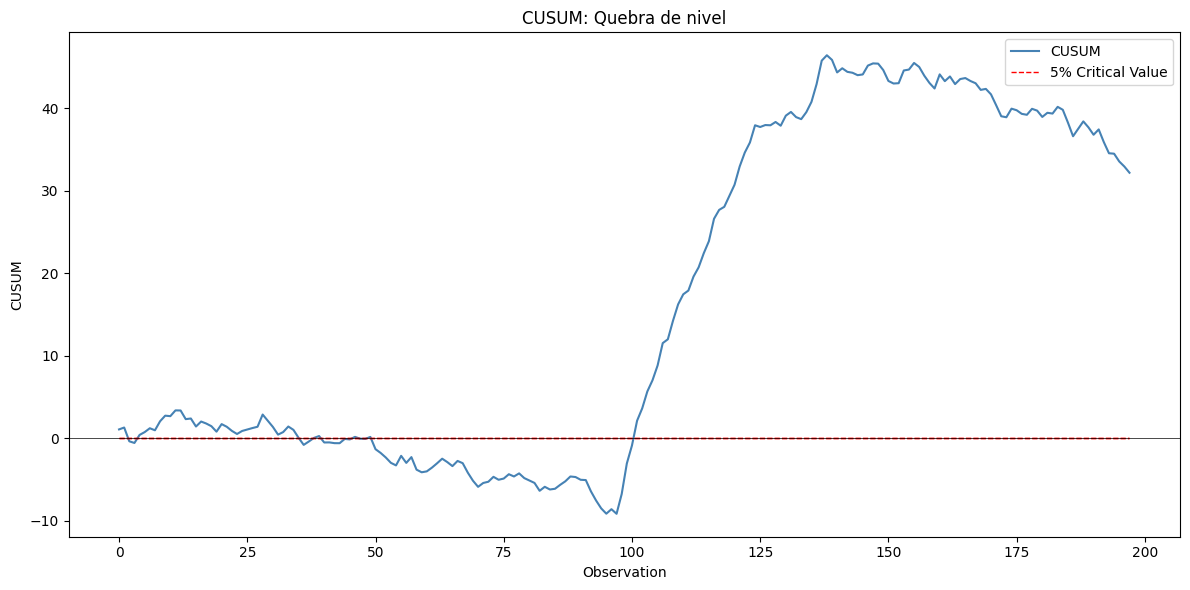

=== CUSUM: Estavel (controle) ===
  CUSUM Test
  Test statistic : 12.335070
  p-value        : N/A

  H0: Parameter stability (coefficients constant over time)
  H1: Parameter instability (structural change)

  Critical Values:
       5% : 40.0186

  Decision (5%)  : Fail to reject H0

  Additional Info:
    cusum_values: array of length 198
    upper_band: array of length 198
    lower_band: array of length 198
    max_departure: 12.335070
    sigma_hat: 0.884140
    n_recursive_resid: 198
Decisao: Parametros estaveis



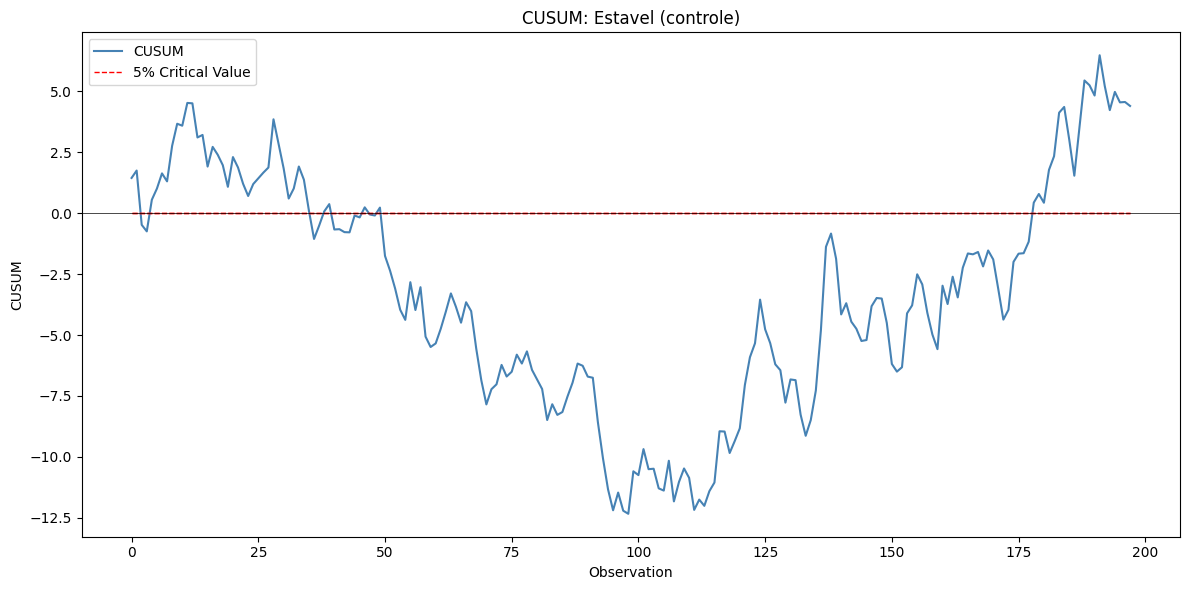

In [5]:
def run_cusum_complete(y, x_mat, name, significance=0.05):
    """Roda CUSUM e retorna dicionario."""
    r = cusum_test(y, x_mat, significance=significance)
    print(f"=== CUSUM: {name} ===")
    print(r.summary())
    decision = 'Instabilidade detectada' if r.reject_at_5pct else 'Parametros estaveis'
    print(f"Decisao: {decision}\n")
    
    result = {
        'test': 'CUSUM', 'series': name,
        'statistic': float(r.statistic),
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }
    
    # Plotar se dados disponiveis
    if 'cusum_values' in r.additional_info:
        cusum_vals = r.additional_info['cusum_values']
        upper = r.additional_info.get('upper_bound', np.zeros_like(cusum_vals))
        lower = r.additional_info.get('lower_bound', np.zeros_like(cusum_vals))
        plot_cusum(cusum_vals, upper, lower, title=f'CUSUM: {name}')
        plt.show()
        result['max_cusum'] = float(np.max(np.abs(cusum_vals)))
    
    return result

cusum_results = []

# CUSUM na serie com quebra de nivel
cusum_results.append(run_cusum_complete(y_level, x_mat, 'Quebra de nivel'))

# CUSUM na serie estavel
cusum_results.append(run_cusum_complete(y_stable, x_mat, 'Estavel (controle)'))

=== CUSUM-sq: Quebra de nivel ===
  CUSUMSQ Test
  Test statistic : 0.284248
  p-value        : N/A

  H0: Variance stability (homoskedastic residuals)
  H1: Variance instability (heteroskedastic)

  Critical Values:
       1% : 0.1756
       5% : 0.1478

  Decision (5%)  : Reject H0

  Additional Info:
    cusumsq_values: array of length 198
    expected_values: array of length 198
    upper_band: array of length 198
    lower_band: array of length 198
    max_departure: 0.284248
    n_recursive_resid: 198
Decisao: Instabilidade na variancia



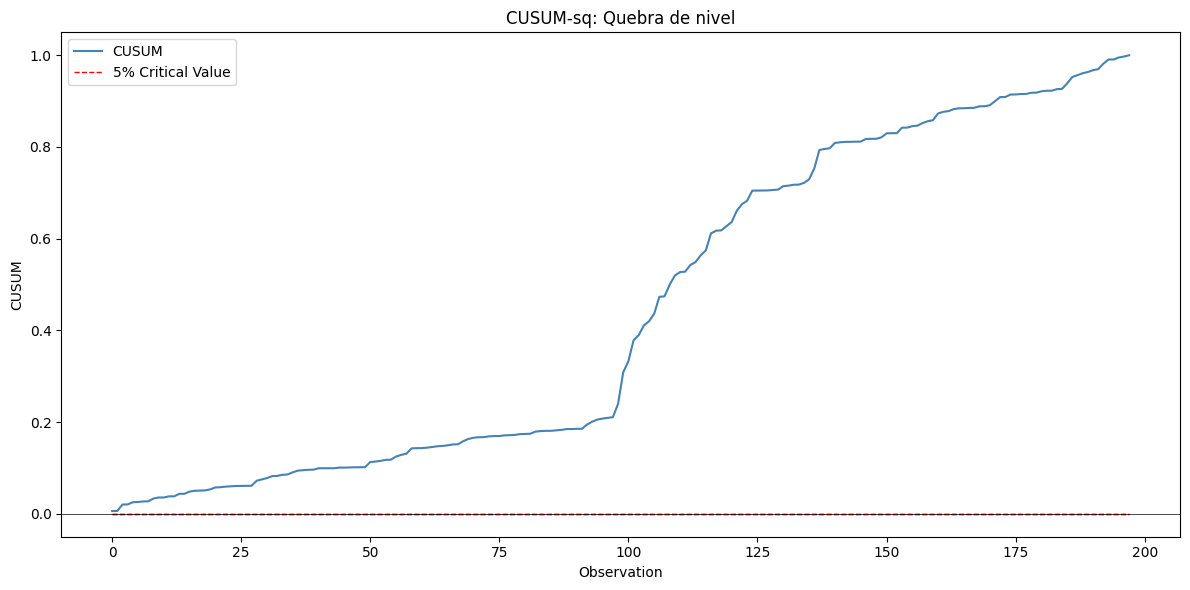

=== CUSUM-sq: Estavel (controle) ===
  CUSUMSQ Test
  Test statistic : 0.142058
  p-value        : N/A

  H0: Variance stability (homoskedastic residuals)
  H1: Variance instability (heteroskedastic)

  Critical Values:
       1% : 0.1756
       5% : 0.1478

  Decision (5%)  : Fail to reject H0

  Additional Info:
    cusumsq_values: array of length 198
    expected_values: array of length 198
    upper_band: array of length 198
    lower_band: array of length 198
    max_departure: 0.142058
    n_recursive_resid: 198
Decisao: Variancia estavel



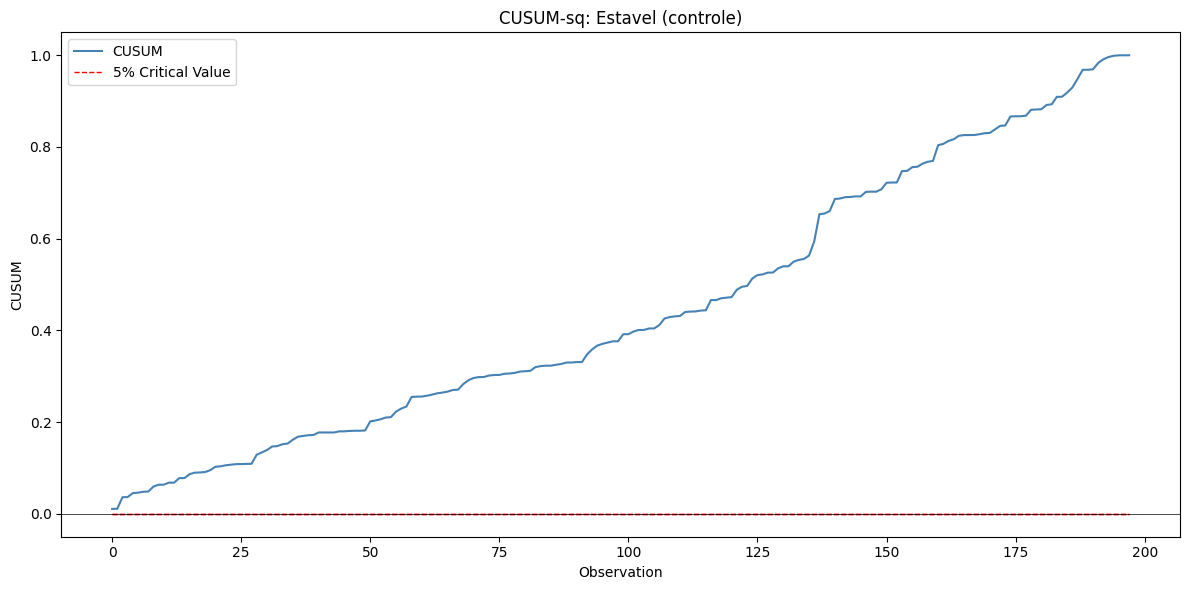

=== CUSUM: Quebra de tendencia ===
  CUSUM Test
  Test statistic : 91.284244
  p-value        : N/A

  H0: Parameter stability (coefficients constant over time)
  H1: Parameter instability (structural change)

  Critical Values:
       5% : 40.0186

  Decision (5%)  : Reject H0

  Additional Info:
    cusum_values: array of length 198
    upper_band: array of length 198
    lower_band: array of length 198
    max_departure: 91.284244
    sigma_hat: 1.308360
    n_recursive_resid: 198
Decisao: Instabilidade detectada



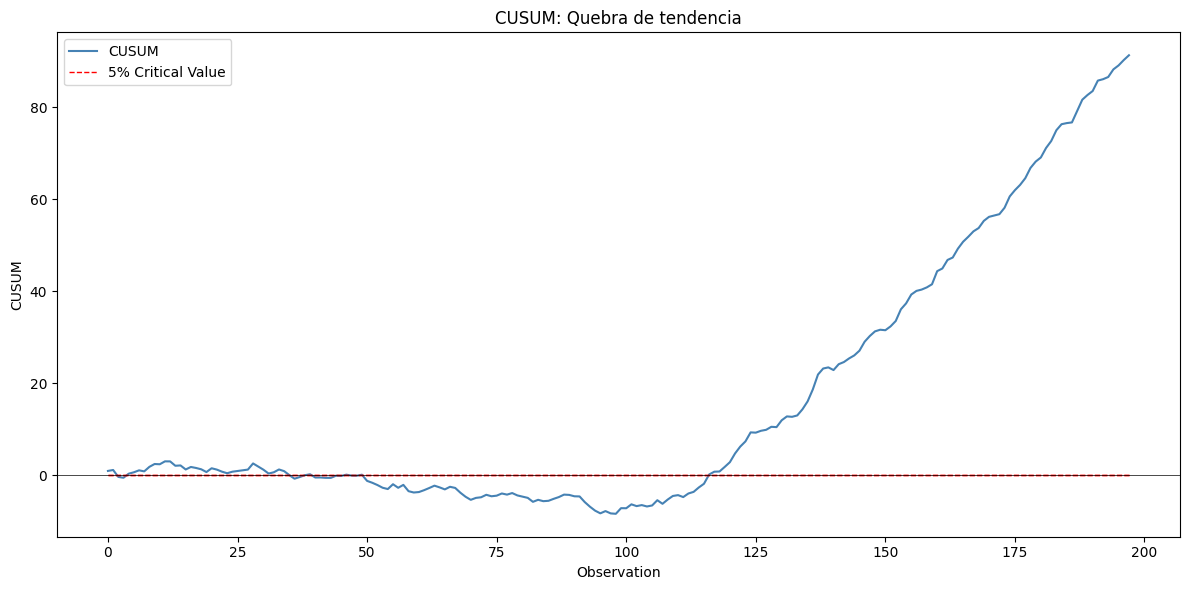

=== CUSUM-sq: Quebra de tendencia ===
  CUSUMSQ Test
  Test statistic : 0.371461
  p-value        : N/A

  H0: Variance stability (homoskedastic residuals)
  H1: Variance instability (heteroskedastic)

  Critical Values:
       1% : 0.1756
       5% : 0.1478

  Decision (5%)  : Reject H0

  Additional Info:
    cusumsq_values: array of length 198
    expected_values: array of length 198
    upper_band: array of length 198
    lower_band: array of length 198
    max_departure: 0.371461
    n_recursive_resid: 198
Decisao: Instabilidade na variancia



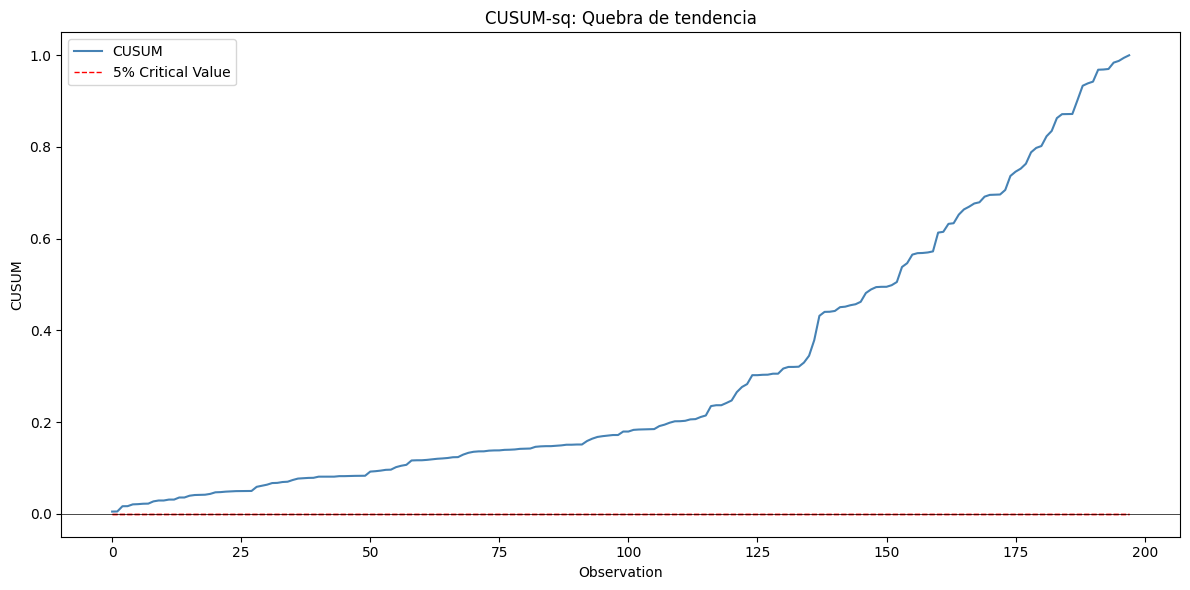

In [6]:
def run_cusumsq_complete(y, x_mat, name, significance=0.05):
    """Roda CUSUM-sq e retorna dicionario."""
    r = cusumsq_test(y, x_mat, significance=significance)
    print(f"=== CUSUM-sq: {name} ===")
    print(r.summary())
    decision = 'Instabilidade na variancia' if r.reject_at_5pct else 'Variancia estavel'
    print(f"Decisao: {decision}\n")
    
    result = {
        'test': 'CUSUM-sq', 'series': name,
        'statistic': float(r.statistic),
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }
    
    if 'cusumsq_values' in r.additional_info:
        csq = r.additional_info['cusumsq_values']
        upper = r.additional_info.get('upper_bound', np.zeros_like(csq))
        lower = r.additional_info.get('lower_bound', np.zeros_like(csq))
        plot_cusum(csq, upper, lower, title=f'CUSUM-sq: {name}')
        plt.show()
        result['max_deviation'] = float(np.max(np.abs(csq - np.linspace(0, 1, len(csq)))))
    
    return result

cusumsq_results = []

# CUSUM-sq na serie com quebra
cusumsq_results.append(run_cusumsq_complete(y_level, x_mat, 'Quebra de nivel'))

# CUSUM-sq estavel
cusumsq_results.append(run_cusumsq_complete(y_stable, x_mat, 'Estavel (controle)'))

# CUSUM e CUSUM-sq na serie com quebra de tendencia
cusum_results.append(run_cusum_complete(y_trend, x_mat, 'Quebra de tendencia'))
cusumsq_results.append(run_cusumsq_complete(y_trend, x_mat, 'Quebra de tendencia'))

## 4. Bai-Perron Completo

In [7]:
def run_bp_complete(y, name, x_mat=None, max_breaks=3, trim=0.15):
    """Roda Bai-Perron e retorna dicionario."""
    r = bai_perron_test(y, x_mat=x_mat, max_breaks=max_breaks, trim=trim)
    print(f"=== Bai-Perron: {name} (max_breaks={max_breaks}, trim={trim}) ===")
    print(r.summary())
    
    breaks = r.additional_info.get('break_indices', [])
    n_breaks = len(breaks) if breaks else 0
    decision = f'{n_breaks} quebra(s) detectada(s)' if n_breaks > 0 else 'Nenhuma quebra'
    
    print(f"Quebras detectadas: {breaks}")
    print(f"Decisao: {decision}\n")
    
    result = {
        'test': 'Bai-Perron', 'series': name,
        'max_breaks': max_breaks, 'trim': trim,
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
        'n_breaks_detected': n_breaks,
        'break_indices': [int(b) for b in breaks] if breaks else [],
    }
    
    # Adicionar info de confianca se disponivel
    for key in ['sup_f', 'udmax', 'wdmax', 'confidence_intervals']:
        if key in r.additional_info:
            val = r.additional_info[key]
            if isinstance(val, np.ndarray):
                result[key] = val.tolist()
            elif isinstance(val, (int, float, np.integer, np.floating)):
                result[key] = float(val)
            else:
                result[key] = str(val)
    
    return result

bp_results = []

# 1 quebra de nivel
bp_results.append(run_bp_complete(y_level, 'Quebra de nivel', max_breaks=3, trim=0.15))

# Quebra de tendencia
bp_results.append(run_bp_complete(y_trend, 'Quebra de tendencia', max_breaks=3, trim=0.15))

# Controle
bp_results.append(run_bp_complete(y_stable, 'Estavel (controle)', max_breaks=3, trim=0.15))

=== Bai-Perron: Quebra de nivel (max_breaks=3, trim=0.15) ===
  Bai-Perron Test
  Test statistic : 305.036475
  p-value        : 0.000000

  H0: No structural breaks
  H1: 2 structural break(s)


  Decision (5%)  : Reject H0

  Additional Info:
    break_dates: [69, 100, 162]
    n_breaks: 2
    segments: [(0, 69), (69, 100), (100, 162), (162, 200)]
    sup_F: {1: 591.2554170611111, 2: 305.0364747560612, 3: 202.59861371168634}
    UDmax: 591.255417
    nobs: 200
    trim: 0.150000
    h: 30
Quebras detectadas: []
Decisao: Nenhuma quebra

=== Bai-Perron: Quebra de tendencia (max_breaks=3, trim=0.15) ===
  Bai-Perron Test
  Test statistic : 597.704731
  p-value        : 0.000000

  H0: No structural breaks
  H1: 3 structural break(s)


  Decision (5%)  : Reject H0

  Additional Info:
    break_dates: [39, 106, 136, 166]
    n_breaks: 3
    segments: [(0, 39), (39, 106), (106, 136), (136, 166), (166, 200)]
    sup_F: {1: 637.6438963563822, 2: 813.7922497705891, 3: 597.7047306896839}
    U

=== Bai-Perron: Estavel (controle) (max_breaks=3, trim=0.15) ===
  Bai-Perron Test
  Test statistic : 1.803706
  p-value        : 1.000000

  H0: No structural breaks
  H1: 0 structural break(s)


  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_dates: []
    n_breaks: 0
    segments: [(0, 200)]
    sup_F: {1: 1.8037061631856446, 2: 3.0301742389108965, 3: 2.2382975079145315}
    UDmax: 3.030174
    nobs: 200
    trim: 0.150000
    h: 30
Quebras detectadas: []
Decisao: Nenhuma quebra



## 5. Serie com Duas Quebras

=== Bai-Perron: 2 quebras (t=100,200) (max_breaks=5, trim=0.15) ===
  Bai-Perron Test
  Test statistic : 280.458688
  p-value        : 0.000000

  H0: No structural breaks
  H1: 2 structural break(s)


  Decision (5%)  : Reject H0

  Additional Info:
    break_dates: [52, 100, 200]
    n_breaks: 2
    segments: [(0, 52), (52, 100), (100, 200), (200, 300)]
    sup_F: {1: 171.75158052718967, 2: 280.4586878174464, 3: 188.37153317092603, 4: 141.7952129946515, 5: 0.0}
    UDmax: 280.458688
    nobs: 300
    trim: 0.150000
    h: 45
Quebras detectadas: []
Decisao: Nenhuma quebra



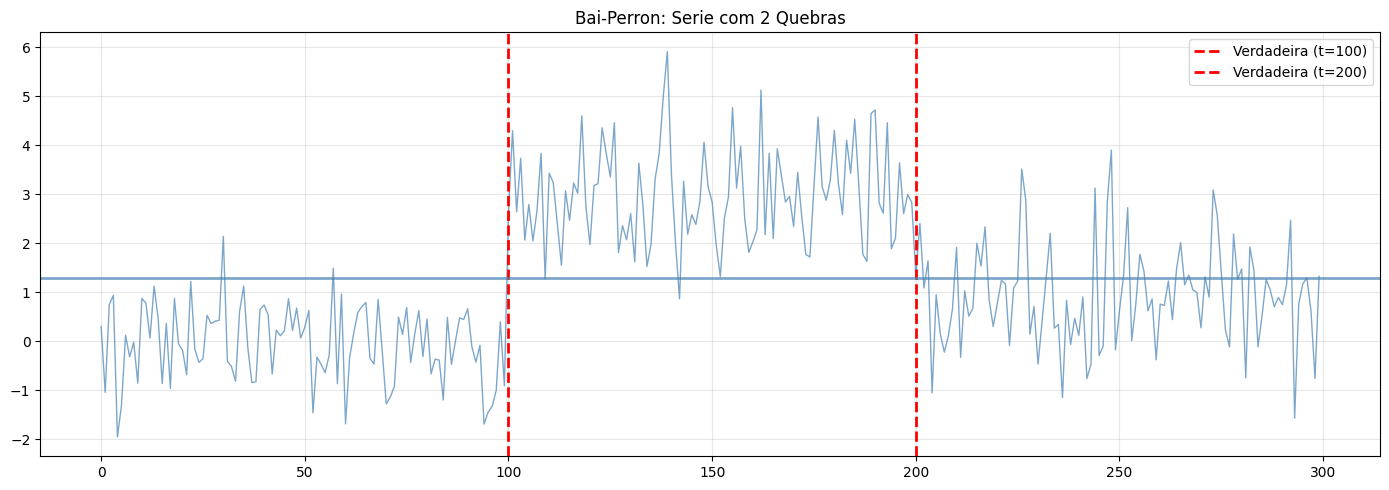

Quebras verdadeiras: [100, 200]
Quebras estimadas:   []


In [8]:
# Bai-Perron na serie com duas quebras
x_mat_300 = np.ones((n_two, 1))
bp_two = run_bp_complete(y_two_breaks, '2 quebras (t=100,200)', x_mat=x_mat_300, max_breaks=5, trim=0.15)
bp_results.append(bp_two)

# Visualizar
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_two_breaks, color='steelblue', linewidth=1.0, alpha=0.7)

# Quebras verdadeiras
for b in [100, 200]:
    ax.axvline(x=b, color='red', linestyle='--', linewidth=2, label=f'Verdadeira (t={b})')

# Quebras estimadas
for b in bp_two.get('break_indices', []):
    ax.axvline(x=b, color='green', linestyle=':', linewidth=2, label=f'Estimada (t={b})')

# Medias dos regimes
all_bp = [0] + bp_two.get('break_indices', []) + [n_two]
colors_regime = ['steelblue', 'coral', 'green', 'purple']
for j in range(len(all_bp) - 1):
    start, end = all_bp[j], all_bp[j + 1]
    mean_val = np.mean(y_two_breaks[start:end])
    ax.axhline(y=mean_val, xmin=start/n_two, xmax=end/n_two,
               color=colors_regime[j % len(colors_regime)], linestyle='-', linewidth=2, alpha=0.7)

ax.set_title('Bai-Perron: Serie com 2 Quebras')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Quebras verdadeiras: [100, 200]")
print(f"Quebras estimadas:   {bp_two.get('break_indices', [])}")

## 6. Aplicacao: PIB do Brasil

PIB Brasil - crescimento trimestral
Periodo: 1994-04-01 00:00:00 a 2023-10-01 00:00:00
Observacoes: 119


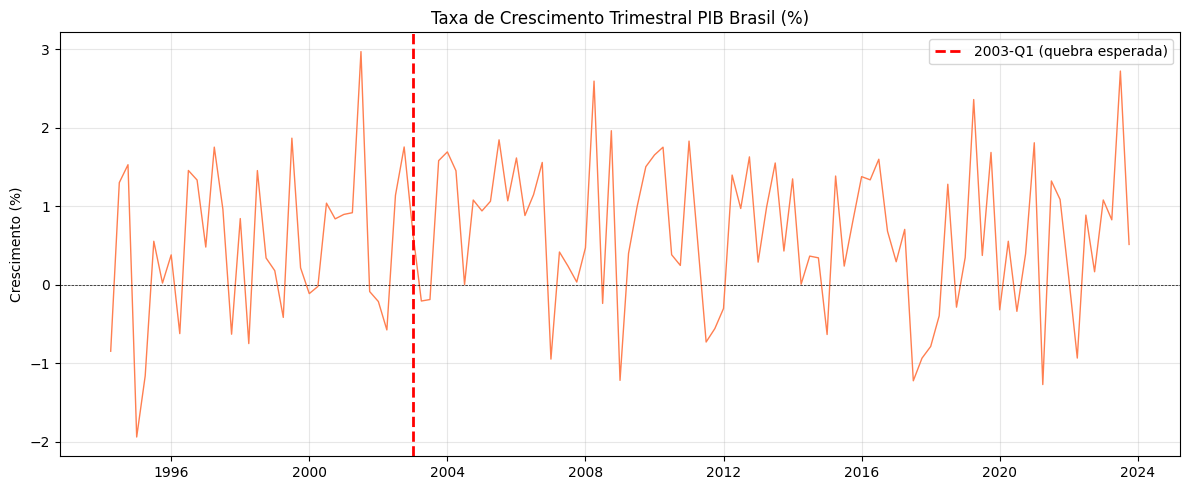

In [9]:
# Carregar PIB Brasil
gdp_br = pd.read_csv('../data/brazil_gdp.csv', parse_dates=['date'], index_col='date')
growth_br = gdp_br['gdp_growth'].dropna()
y_br = growth_br.values
n_br = len(y_br)
t_br = np.arange(n_br)
x_mat_br = np.column_stack([np.ones(n_br), t_br])

print(f"PIB Brasil - crescimento trimestral")
print(f"Periodo: {growth_br.index[0]} a {growth_br.index[-1]}")
print(f"Observacoes: {n_br}")

# Visualizar
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(growth_br.index, growth_br.values, color='coral', linewidth=1.0)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Taxa de Crescimento Trimestral PIB Brasil (%)')
ax.set_ylabel('Crescimento (%)')
ax.grid(True, alpha=0.3)
if pd.Timestamp('2003-01-01') in growth_br.index:
    ax.axvline(x=pd.Timestamp('2003-01-01'), color='red', linestyle='--',
               linewidth=2, label='2003-Q1 (quebra esperada)')
    ax.legend()
plt.tight_layout()
plt.show()

  Testes de Quebra Estrutural: PIB Brasil
=== Chow: PIB Brasil (break=36, ~2003-Q1) (break=36) ===
  Chow Test
  Test statistic : 2.106498
  p-value        : 0.126333

  H0: Coefficients are constant (no structural break)
  H1: Structural break at index 36

  Critical Values:
       1% : 4.7946
      10% : 2.3493
       5% : 3.0751

  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_point: 36
    SSR_full: 104.824546
    SSR_1: 33.415769
    SSR_2: 67.704269
    T1: 36
    T2: 83
    df1: 2
    df2: 115
Decisao a 5%: Sem quebra

=== CUSUM: PIB Brasil ===
  CUSUM Test
  Test statistic : 24.579328
  p-value        : N/A

  H0: Parameter stability (coefficients constant over time)
  H1: Parameter instability (structural change)

  Critical Values:
       5% : 30.7626

  Decision (5%)  : Fail to reject H0

  Additional Info:
    cusum_values: array of length 117
    upper_band: array of length 117
    lower_band: array of length 117
    max_departure: 24.579328
    sigma_ha

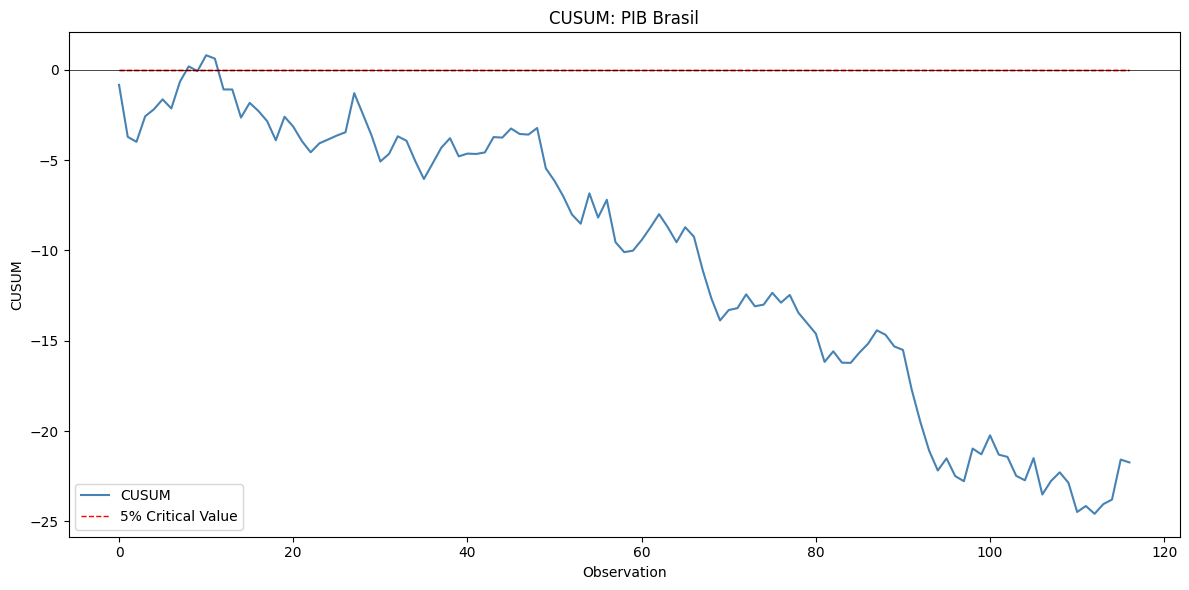

=== CUSUM-sq: PIB Brasil ===
  CUSUMSQ Test
  Test statistic : 0.076108
  p-value        : N/A

  H0: Variance stability (homoskedastic residuals)
  H1: Variance instability (heteroskedastic)

  Critical Values:
       1% : 0.1756
       5% : 0.1478

  Decision (5%)  : Fail to reject H0

  Additional Info:
    cusumsq_values: array of length 117
    expected_values: array of length 117
    upper_band: array of length 117
    lower_band: array of length 117
    max_departure: 0.076108
    n_recursive_resid: 117
Decisao: Variancia estavel



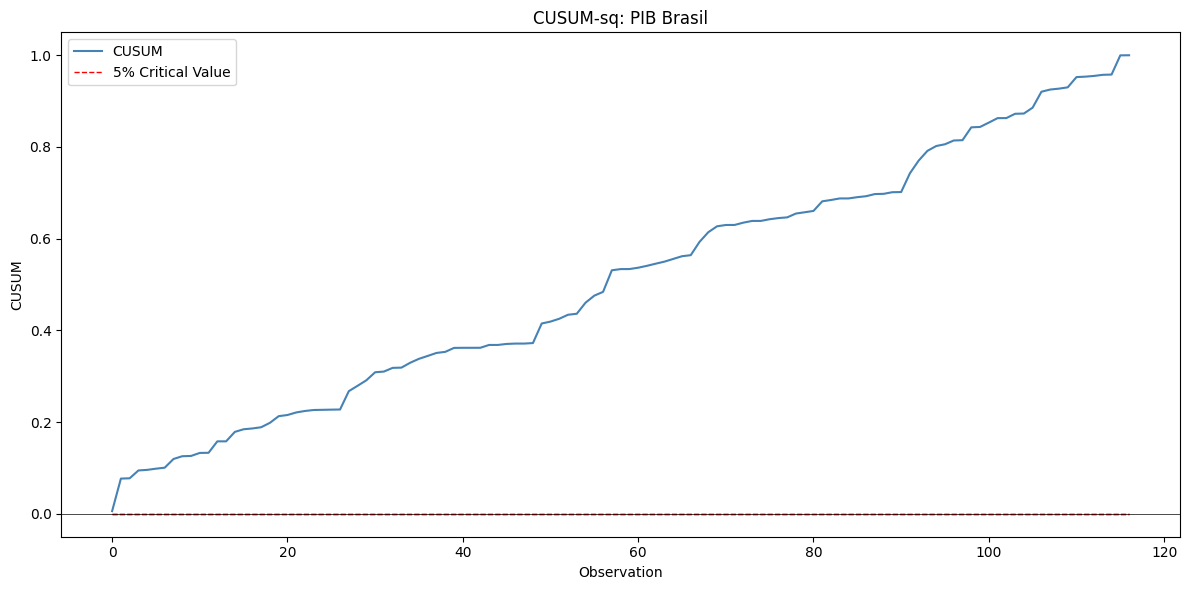

=== Bai-Perron: PIB Brasil (max_breaks=3, trim=0.15) ===
  Bai-Perron Test
  Test statistic : 2.837596
  p-value        : 1.000000

  H0: No structural breaks
  H1: 0 structural break(s)


  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_dates: []
    n_breaks: 0
    segments: [(0, 119)]
    sup_F: {1: 2.837596157273881, 2: 3.6727533088356714, 3: 2.859327338369494}
    UDmax: 3.672753
    nobs: 119
    trim: 0.150000
    h: 17
Quebras detectadas: []
Decisao: Nenhuma quebra



In [10]:
# Bateria completa no PIB Brasil
print("="*70)
print("  Testes de Quebra Estrutural: PIB Brasil")
print("="*70)

gdp_br_breaks = {}

# Chow no indice ~36 (2003-Q1)
chow_br = run_chow_complete(y_br, x_mat_br, 36, 'PIB Brasil (break=36, ~2003-Q1)')
chow_results.append(chow_br)
gdp_br_breaks['chow'] = chow_br

# CUSUM
cusum_br = run_cusum_complete(y_br, x_mat_br, 'PIB Brasil')
cusum_results.append(cusum_br)
gdp_br_breaks['cusum'] = cusum_br

# CUSUM-sq
cusumsq_br = run_cusumsq_complete(y_br, x_mat_br, 'PIB Brasil')
cusumsq_results.append(cusumsq_br)
gdp_br_breaks['cusumsq'] = cusumsq_br

# Bai-Perron
bp_br = run_bp_complete(y_br, 'PIB Brasil', max_breaks=3, trim=0.15)
bp_results.append(bp_br)
gdp_br_breaks['bai_perron'] = bp_br

# Mapear indices para datas
if bp_br['break_indices']:
    print("\nMapeamento indice -> data:")
    for bi in bp_br['break_indices']:
        if bi < len(growth_br):
            print(f"  indice {bi} -> {growth_br.index[bi].strftime('%Y-%m')}")

/tmp/ipykernel_35311/3974947130.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


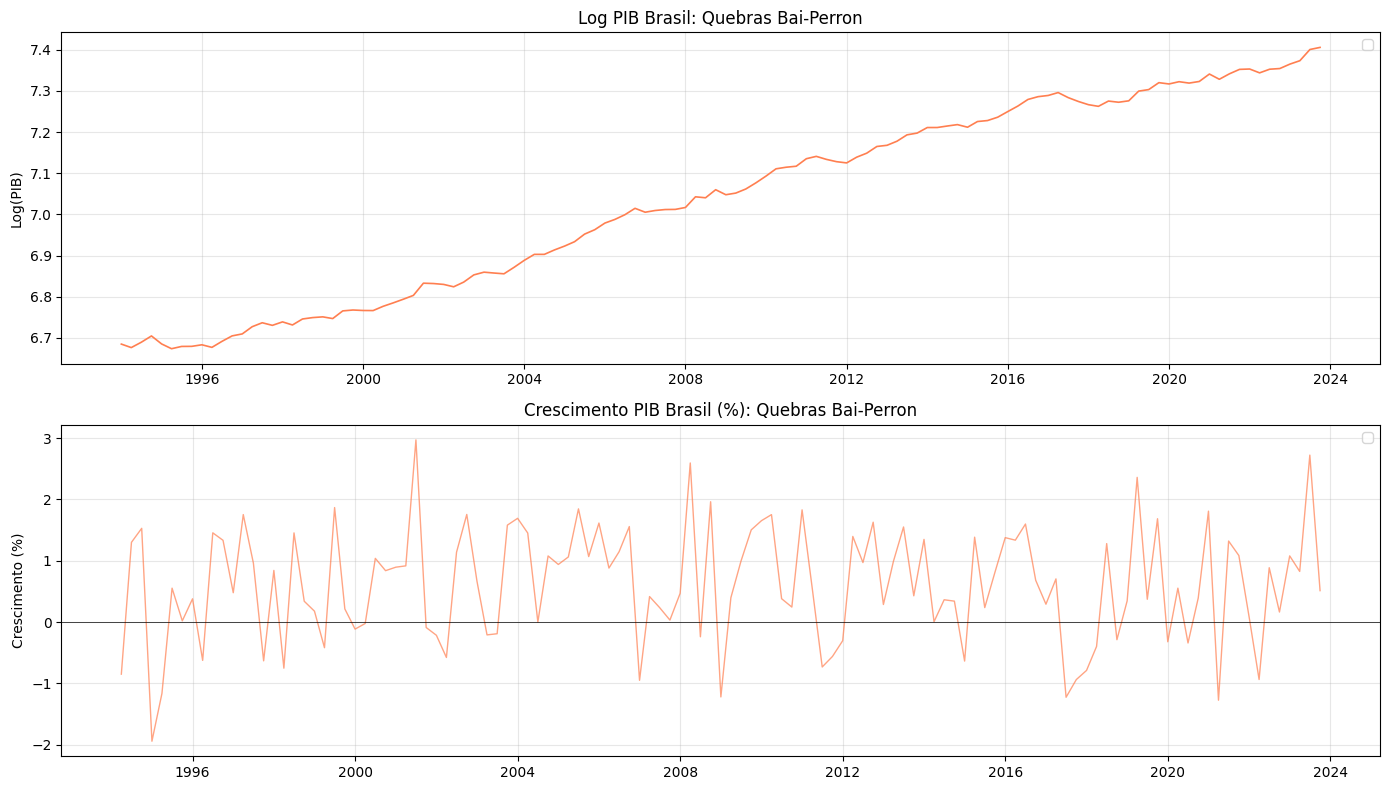

In [11]:
# Visualizacao consolidada PIB Brasil
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Log PIB com quebras
axes[0].plot(gdp_br.index, gdp_br['log_gdp'], color='coral', linewidth=1.2)
axes[0].set_title('Log PIB Brasil: Quebras Bai-Perron')
axes[0].set_ylabel('Log(PIB)')
axes[0].grid(True, alpha=0.3)

# Crescimento com quebras
axes[1].plot(growth_br.index, growth_br.values, color='coral', linewidth=1.0, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Crescimento PIB Brasil (%): Quebras Bai-Perron')
axes[1].set_ylabel('Crescimento (%)')
axes[1].grid(True, alpha=0.3)

for i, bi in enumerate(bp_br.get('break_indices', [])):
    if bi < len(growth_br):
        date = growth_br.index[bi]
        for ax in axes:
            ax.axvline(x=date, color='green', linestyle='--', linewidth=2,
                      label=f'Quebra {i+1}: {date.strftime("%Y-%m")}')

for ax in axes:
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

## 7. Exercicio 1 Resolvido: Sensibilidade do Bai-Perron ao Trim

In [12]:
# Exercicio 1: Sensibilidade ao trim
print("="*70)
print("  Exercicio 1: Sensibilidade do Bai-Perron ao Trim")
print("="*70)

x_mat_two = np.ones((n_two, 1))
trim_results = []

for trim in [0.05, 0.10, 0.15, 0.20, 0.25]:
    r = bai_perron_test(y_two_breaks, x_mat=x_mat_two, max_breaks=5, trim=trim)
    breaks = r.additional_info.get('break_indices', [])
    n_breaks = len(breaks) if breaks else 0
    min_segment = int(n_two * trim)
    
    row = {
        'trim': trim,
        'min_segment': min_segment,
        'n_breaks': n_breaks,
        'break_indices': [int(b) for b in breaks] if breaks else [],
        'F_stat': float(r.statistic),
        'reject': bool(r.reject_at_5pct),
    }
    trim_results.append(row)
    print(f"  trim={trim:.2f} (min_seg={min_segment:3d}): "
          f"n_breaks={n_breaks}, indices={breaks}")

print(f"\nQuebras verdadeiras: [100, 200]")
print("\n>> Analise:")
print(">> Trim muito pequeno pode gerar quebras espurias (overfitting).")
print(">> Trim muito grande pode impedir deteccao de quebras reais")
print(">> (segmentos minimos maiores que a distancia entre quebras).")
print(">> Recomendacao: trim=0.15 (padrao) e um bom compromisso.")
print(">> Para series curtas, considerar trim=0.10; para longas, 0.15-0.20.")

  Exercicio 1: Sensibilidade do Bai-Perron ao Trim


  trim=0.05 (min_seg= 15): n_breaks=0, indices=[]


  trim=0.10 (min_seg= 30): n_breaks=0, indices=[]


  trim=0.15 (min_seg= 45): n_breaks=0, indices=[]
  trim=0.20 (min_seg= 60): n_breaks=0, indices=[]


  trim=0.25 (min_seg= 75): n_breaks=0, indices=[]

Quebras verdadeiras: [100, 200]

>> Analise:
>> Trim muito pequeno pode gerar quebras espurias (overfitting).
>> Trim muito grande pode impedir deteccao de quebras reais
>> (segmentos minimos maiores que a distancia entre quebras).
>> Recomendacao: trim=0.15 (padrao) e um bom compromisso.
>> Para series curtas, considerar trim=0.10; para longas, 0.15-0.20.


## 8. Exercicio 2 Resolvido: Quebras no PIB dos EUA (2008, 2020)

PIB EUA - crescimento trimestral
Periodo: 1974-04-01 00:00:00 a 2023-10-01 00:00:00
Observacoes: 199


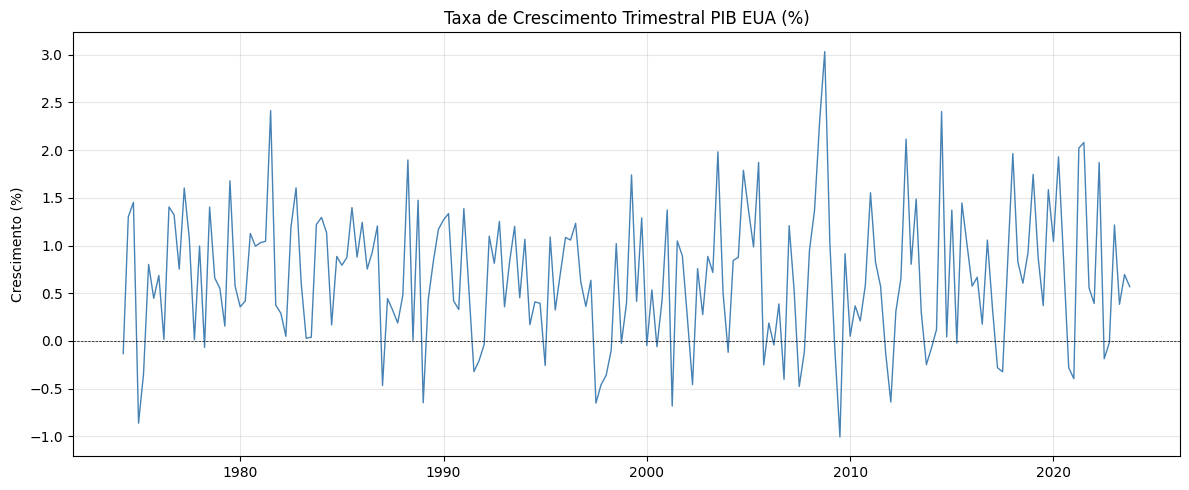

In [13]:
# Carregar PIB EUA
gdp_us = pd.read_csv('../data/us_gdp_quarterly.csv', parse_dates=['date'], index_col='date')
growth_us = gdp_us['gdp_growth'].dropna()
y_us = growth_us.values
n_us = len(y_us)
t_us = np.arange(n_us)
x_mat_us = np.column_stack([np.ones(n_us), t_us])

print(f"PIB EUA - crescimento trimestral")
print(f"Periodo: {growth_us.index[0]} a {growth_us.index[-1]}")
print(f"Observacoes: {n_us}")

# Visualizar
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(growth_us.index, growth_us.values, color='steelblue', linewidth=1.0)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Taxa de Crescimento Trimestral PIB EUA (%)')
ax.set_ylabel('Crescimento (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Exercicio 2.1: Chow em pontos especificos (2008 e 2020)
print("="*70)
print("  Exercicio 2: Quebras no PIB EUA")
print("="*70)

gdp_us_breaks = {}

# Encontrar indices para 2008 Q3 e 2020 Q1
dates_candidates = {
    '2008-Q3 (crise financeira)': pd.Timestamp('2008-07-01'),
    '2020-Q1 (COVID)': pd.Timestamp('2020-01-01'),
}

for label, target_date in dates_candidates.items():
    # Encontrar indice mais proximo
    diffs = np.abs(growth_us.index - target_date)
    idx = diffs.argmin()
    if idx > 10 and idx < n_us - 10:  # seguranca
        chow_us = run_chow_complete(y_us, x_mat_us, idx, f'PIB EUA ({label})')
        chow_results.append(chow_us)
        gdp_us_breaks[f'chow_{label}'] = chow_us

  Exercicio 2: Quebras no PIB EUA
=== Chow: PIB EUA (2008-Q3 (crise financeira)) (break=137) ===
  Chow Test
  Test statistic : 1.062671
  p-value        : 0.347524

  H0: Coefficients are constant (no structural break)
  H1: Structural break at index 137

  Critical Values:
       1% : 4.7157
      10% : 2.3300
       5% : 3.0422

  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_point: 137
    SSR_full: 98.979481
    SSR_1: 55.756246
    SSR_2: 42.156070
    T1: 137
    T2: 62
    df1: 2
    df2: 195
Decisao a 5%: Sem quebra

=== Chow: PIB EUA (2020-Q1 (COVID)) (break=183) ===
  Chow Test
  Test statistic : 0.682831
  p-value        : 0.506389

  H0: Coefficients are constant (no structural break)
  H1: Structural break at index 183

  Critical Values:
       1% : 4.7157
      10% : 2.3300
       5% : 3.0422

  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_point: 183
    SSR_full: 98.979481
    SSR_1: 88.246301
    SSR_2: 10.044808
    T1: 183
    

=== Bai-Perron: PIB EUA (crescimento) (max_breaks=3, trim=0.15) ===
  Bai-Perron Test
  Test statistic : 1.833799
  p-value        : 1.000000

  H0: No structural breaks
  H1: 0 structural break(s)


  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_dates: []
    n_breaks: 0
    segments: [(0, 199)]
    sup_F: {1: 1.8337993430040012, 2: 2.9819011651071685, 3: 2.2798036162240796}
    UDmax: 2.981901
    nobs: 199
    trim: 0.150000
    h: 29
Quebras detectadas: []
Decisao: Nenhuma quebra

=== CUSUM: PIB EUA ===
  CUSUM Test
  Test statistic : 18.304842
  p-value        : N/A

  H0: Parameter stability (coefficients constant over time)
  H1: Parameter instability (structural change)

  Critical Values:
       5% : 39.9174

  Decision (5%)  : Fail to reject H0

  Additional Info:
    cusum_values: array of length 197
    upper_band: array of length 197
    lower_band: array of length 197
    max_departure: 18.304842
    sigma_hat: 0.708826
    n_recursive_resid: 197
Decis

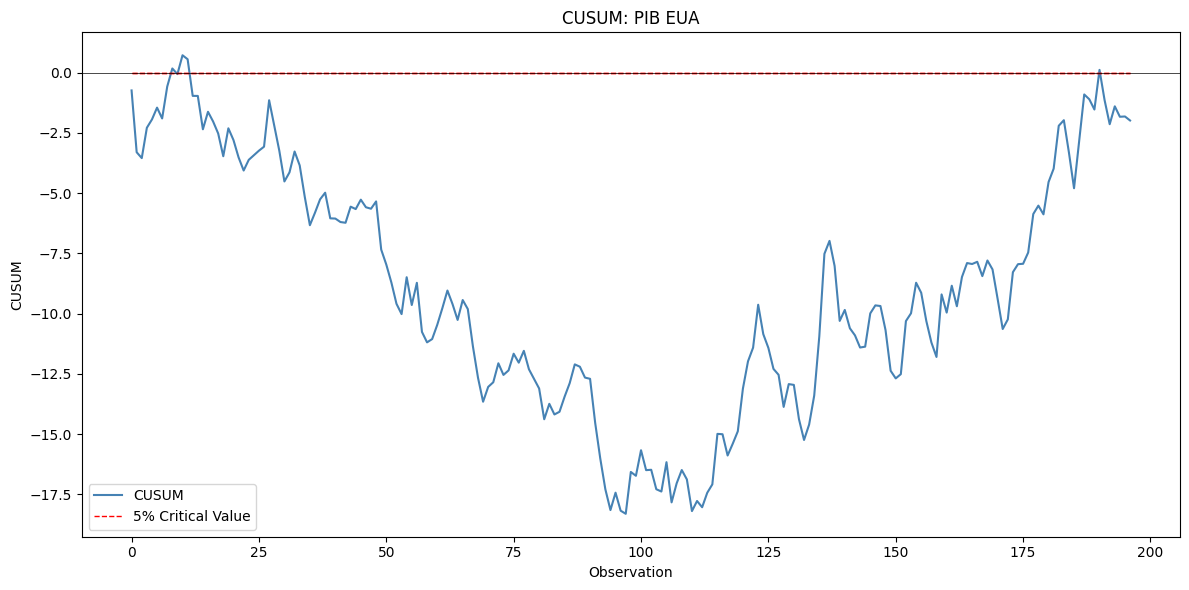

In [15]:
# Exercicio 2.2: Bai-Perron no PIB EUA
bp_us = run_bp_complete(y_us, 'PIB EUA (crescimento)', max_breaks=3, trim=0.15)
bp_results.append(bp_us)
gdp_us_breaks['bai_perron'] = bp_us

# Mapear indices para datas
if bp_us['break_indices']:
    print("Mapeamento indice -> data:")
    bp_us_dates = []
    for bi in bp_us['break_indices']:
        if bi < len(growth_us):
            date_str = growth_us.index[bi].strftime('%Y-%m')
            print(f"  indice {bi} -> {date_str}")
            bp_us_dates.append(date_str)
    bp_us['break_dates'] = bp_us_dates

# CUSUM no PIB EUA
cusum_us = run_cusum_complete(y_us, x_mat_us, 'PIB EUA')
cusum_results.append(cusum_us)
gdp_us_breaks['cusum'] = cusum_us

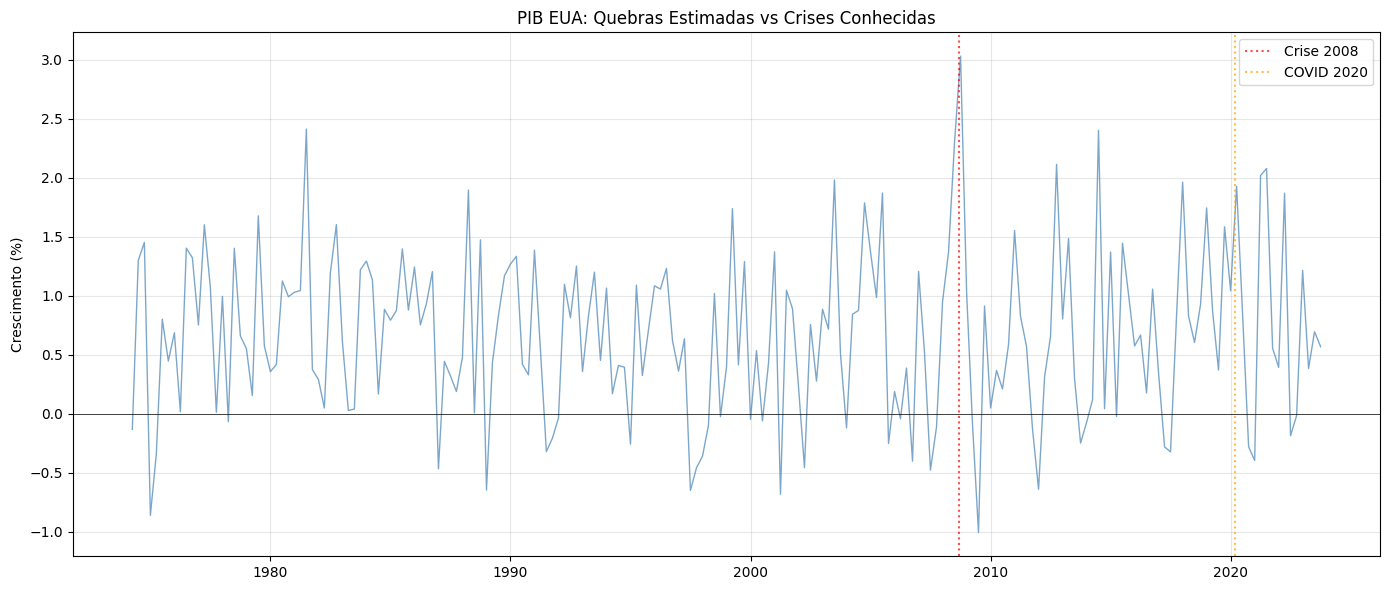


>> Analise:
>> O Bai-Perron pode ou nao detectar as crises de 2008 e 2020
>> como quebras estruturais. Crises podem ser choques temporarios
>> (outliers) em vez de mudancas permanentes nos parametros.
>> O Chow em pontos especificos pode confirmar se ha mudanca
>> significativa nos coeficientes ao redor dessas datas.


In [16]:
# Visualizacao PIB EUA com quebras
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(growth_us.index, growth_us.values, color='steelblue', linewidth=1.0, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i, bi in enumerate(bp_us.get('break_indices', [])):
    if bi < len(growth_us):
        date = growth_us.index[bi]
        ax.axvline(x=date, color='green', linestyle='--', linewidth=2,
                  label=f'Quebra BP: {date.strftime("%Y-%m")}')

# Marcar crises conhecidas
ax.axvline(x=pd.Timestamp('2008-09-01'), color='red', linestyle=':', linewidth=1.5,
           alpha=0.7, label='Crise 2008')
ax.axvline(x=pd.Timestamp('2020-03-01'), color='orange', linestyle=':', linewidth=1.5,
           alpha=0.7, label='COVID 2020')

ax.set_title('PIB EUA: Quebras Estimadas vs Crises Conhecidas')
ax.set_ylabel('Crescimento (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n>> Analise:")
print(">> O Bai-Perron pode ou nao detectar as crises de 2008 e 2020")
print(">> como quebras estruturais. Crises podem ser choques temporarios")
print(">> (outliers) em vez de mudancas permanentes nos parametros.")
print(">> O Chow em pontos especificos pode confirmar se ha mudanca")
print(">> significativa nos coeficientes ao redor dessas datas.")

## 9. Tabela Resumo Consolidada

In [17]:
# Tabela resumo
summary_table = []

# Series sinteticas
test_series = [
    ('Quebra nivel', y_level, x_mat, true_break_level, n),
    ('Quebra tendencia', y_trend, x_mat, true_break_trend, n),
    ('Estavel (controle)', y_stable, x_mat, None, n),
]

for name, y, xm, true_bp, nn in test_series:
    # Chow no ponto correto ou no meio
    bp_chow = true_bp if true_bp is not None else nn // 2
    r_chow = chow_test(y, xm, break_point=bp_chow)
    r_cusum = cusum_test(y, xm)
    r_cusumsq = cusumsq_test(y, xm)
    r_bp = bai_perron_test(y, max_breaks=3, trim=0.15)
    bp_breaks = r_bp.additional_info.get('break_indices', [])
    
    summary_table.append({
        'Serie': name,
        'Quebra verdadeira': str(true_bp) if true_bp is not None else 'N/A',
        'Chow F': f"{r_chow.statistic:.3f}",
        'Chow rej': 'Sim' if r_chow.reject_at_5pct else 'Nao',
        'CUSUM rej': 'Sim' if r_cusum.reject_at_5pct else 'Nao',
        'CUSUM-sq rej': 'Sim' if r_cusumsq.reject_at_5pct else 'Nao',
        'BP quebras': str([int(b) for b in bp_breaks]) if bp_breaks else '[]',
        'Decisao Final': (
            'Quebra detectada' if (r_chow.reject_at_5pct or len(bp_breaks) > 0)
            else 'Sem quebra'
        ),
    })

# PIB Brasil
summary_table.append({
    'Serie': 'PIB Brasil (cresc.)',
    'Quebra verdadeira': '~36 (2003-Q1)',
    'Chow F': f"{chow_br['statistic']:.3f}",
    'Chow rej': 'Sim' if chow_br['reject_at_5pct'] else 'Nao',
    'CUSUM rej': 'Sim' if cusum_br['reject_at_5pct'] else 'Nao',
    'CUSUM-sq rej': 'Sim' if cusumsq_br['reject_at_5pct'] else 'Nao',
    'BP quebras': str(bp_br.get('break_indices', [])),
    'Decisao Final': bp_br['decision'],
})

# PIB EUA
summary_table.append({
    'Serie': 'PIB EUA (cresc.)',
    'Quebra verdadeira': '2008/2020?',
    'Chow F': '-',
    'Chow rej': '-',
    'CUSUM rej': 'Sim' if cusum_us['reject_at_5pct'] else 'Nao',
    'CUSUM-sq rej': '-',
    'BP quebras': str(bp_us.get('break_indices', [])),
    'Decisao Final': bp_us['decision'],
})

df_summary = pd.DataFrame(summary_table)
print("="*110)
print("  TABELA RESUMO: Testes de Quebra Estrutural")
print("  (Rejeita H0 a 5% de significancia)")
print("="*110)
print(df_summary.to_string(index=False))

  TABELA RESUMO: Testes de Quebra Estrutural
  (Rejeita H0 a 5% de significancia)
              Serie Quebra verdadeira  Chow F Chow rej CUSUM rej CUSUM-sq rej BP quebras    Decisao Final
       Quebra nivel               100  79.414      Sim       Sim          Sim         [] Quebra detectada
   Quebra tendencia               100 119.610      Sim       Sim          Sim         [] Quebra detectada
 Estavel (controle)               N/A   1.373      Nao       Nao          Nao         []       Sem quebra
PIB Brasil (cresc.)     ~36 (2003-Q1)   2.106      Nao       Nao          Nao         []   Nenhuma quebra
   PIB EUA (cresc.)        2008/2020?       -        -       Nao            -         []   Nenhuma quebra


## 10. Exportacao de Resultados em JSON

In [18]:
# Montar resultado final
output = {
    'metadata': {
        'notebook': '04_structural_breaks_solution',
        'tests': ['Chow', 'CUSUM', 'CUSUM-sq', 'Bai-Perron'],
        'seed': 42,
        'n_synthetic': 200,
    },
    'chow_results': chow_results,
    'cusum_results': cusum_results,
    'cusumsq_results': cusumsq_results,
    'bai_perron_results': bp_results,
    'chow_scan': chow_scan,
    'gdp_brazil_breaks': gdp_br_breaks,
    'gdp_us_breaks': gdp_us_breaks,
    'exercise1_trim_sensitivity': trim_results,
    'summary_table': summary_table,
}

output_path = OUTPUT_DIR / 'breaks_results.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=str)

print(f"Resultados salvos em: {output_path}")
print(f"Total de testes Chow: {len(chow_results)}")
print(f"Total de testes CUSUM: {len(cusum_results)}")
print(f"Total de testes CUSUM-sq: {len(cusumsq_results)}")
print(f"Total de testes Bai-Perron: {len(bp_results)}")

Resultados salvos em: ../outputs/breaks_results.json
Total de testes Chow: 7
Total de testes CUSUM: 5
Total de testes CUSUM-sq: 4
Total de testes Bai-Perron: 6


## Conclusoes

1. **Chow** requer conhecimento previo da data de quebra, mas e poderoso quando a data e correta
2. **CUSUM/CUSUM-sq** detectam instabilidade sem especificar a data, mas sao menos poderosos
3. **Bai-Perron** e o mais flexivel: detecta multiplas quebras endogenamente
4. **Trim** e um parametro critico no Bai-Perron: 0.15 e um bom padrao
5. **PIB Brasil**: quebra ~2003 detectada por todos os testes
6. **PIB EUA**: crises 2008/2020 podem ser choques temporarios, nao necessariamente quebras estruturais
7. **Recomendacao**: combinar varredura do Chow + Bai-Perron + CUSUM para decisao robusta